# Employee Attrition and Workforce Analytics: Identifying Drivers of Employee Turnover

**Capstone Project - Project 7 | India Data Research Academy (IDRA) - Data Science & AI Training Program**

Prepared by: **Harshil Patel**

## 1. Introduction

Employee leaving the company is a big problem. Company lose time, money and experience. HR team wants to know **why employees leave**.

We have **1470 employees and 35 columns** of data. Our question is simple:

> Can we predict which employee will leave the company?

We clean the data, see the patterns with charts and statistics, and build **two machine learning models** to predict **Attrition** (Yes = left, No = stayed).

## 2. Objectives and Research Questions

1. Understand the dataset - structure, columns and data quality.
2. Clean the data and explain every cleaning decision with reason.
3. Use statistics (mean, median, IQR, correlation, probability) to find factors connected with attrition.
4. Build a **classification model** to predict employee attrition.
5. Check the model with **accuracy, precision, recall and F1-score**.
6. Give simple and data-backed recommendations to HR.

Research question: **Which employee is most likely to leave the company?**

## 3. Importing the Libraries

We use `pandas` for tables, `matplotlib`/`seaborn` for charts, and `scikit-learn` for machine learning.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid") ## Set a clean white background with gridlines for clear visual readability across all plots
plt.rcParams["figure.facecolor"] = "white" # Set the background color of all figures to white for a consistent and professional appearance

print("All libraries imported successfully! We are ready to start.")

All libraries imported successfully! We are ready to start.


**Insight:** All libraries are ready. Now we can make tables, charts and machine learning models.

## 4. Loading the Dataset

We load the CSV file given for Project 7 in the LMS. This file has data of 1470 employees.

In [ ]:
data = pd.read_csv("p7.csv")
print("Data loaded successfully!")
data.head(10)

Data loaded successfully!


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


**Insight:** Data loaded successfully. We have 1470 employees and 35 columns of information.

## 5. Understanding the Dataset

First we check the size of the data, the column names and the data types. This tells us which column is a number and which column is a category.

In [32]:
print("How big is the dataset:")
print(data.shape[0], "rows x", data.shape[1], "columns")

How big is the dataset:
1470 rows x 35 columns


In [33]:
print("List of all columns:")
print(list(data.columns))

List of all columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [34]:
print("Data types of all columns:")
print(data.dtypes)

Data types of all columns:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel            

**Insight:** Data has 1470 rows and 35 columns. Some columns are category (JobRole, Department) and some are number (Age, MonthlyIncome).

### A closer look at some important columns

`Attrition` and `OverTime` are Yes/No answers. `Department` has 3 options. The last print shows how many unique values each column has.

In [35]:
print("Basic summary of the numbers:")
data.describe()

Basic summary of the numbers:


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**Insight:** Salary range is very wide (from $1,009 to $19,999) and mean (6503) is bigger than median (4919). So income seems right-skewed. We will check this again in the statistics part.

In [36]:
print("Attrition - how many left and how many stayed:")
print(data["Attrition"].value_counts())

Attrition - how many left and how many stayed:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [37]:
print("OverTime workers vs normal workers:")
print(data["OverTime"].value_counts())

OverTime workers vs normal workers:
OverTime
No     1054
Yes     416
Name: count, dtype: int64


In [38]:
print("Employees in each department:")
print(data["Department"].value_counts())


Employees in each department:
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64


In [39]:
print("Unique values in each column:")
print(data.nunique())

Unique values in each column:
Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimes

**Insight:** Only 237 employees (16.1%) left and 1233 stayed. This is imbalanced data - this point is important when we judge model accuracy.

## 6. Data Quality Check

Before cleaning we check: missing values, duplicate rows, and columns which have only one value (these columns cannot help in prediction).

In [40]:
print("Checking missing values...")
print(data.isnull().sum())

Checking missing values...
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurren

In [41]:
print("Total missing values =", data.isnull().sum().sum())
print("Duplicate rows =", data.duplicated().sum())

Total missing values = 0
Duplicate rows = 0


In [42]:
print("These columns have only 1 unique value (useless for prediction):")
print([col for col in data.columns if data[col].nunique() == 1])

These columns have only 1 unique value (useless for prediction):
['EmployeeCount', 'Over18', 'StandardHours']


**Insight:** Good news - no missing value and no duplicate row. And EmployeeCount, Over18, StandardHours have only 1 value, so they cannot help prediction.

## 7. Data Cleaning

Simple cleaning, and every decision has a reason:

1. **Attrition** and **OverTime** are Yes/No answers, so we change them into **1/0** for the models.
2. **EmployeeCount**, **Over18** and **StandardHours** have the same value for every employee. They have zero information, so we drop them.
3. **EmployeeNumber** is just an ID number. It is not a feature, so we drop it too.

In [43]:
data["Attrition"] = data["Attrition"].map({"Yes": 1, "No": 0})
data["OverTime"]  = data["OverTime"].map({"Yes": 1, "No": 0})

data = data.drop(columns=["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"])

print("Cleaning done! Now the data have:")
print(data.shape[0], "rows,", data.shape[1], "columns")
print()
print("Attrition values are now 1/0:")
print(data["Attrition"].value_counts())
print("Attrition rate = {:.1f}%".format(data["Attrition"].mean() * 100))

Cleaning done! Now the data have:
1470 rows, 31 columns

Attrition values are now 1/0:
Attrition
0    1233
1     237
Name: count, dtype: int64
Attrition rate = 16.1%


**Insight:** Cleaning done. Now 1470 rows and 31 columns. Attrition and OverTime are now 1/0, useless columns are removed.

## 8. Outlier Check using the IQR Rule

From the statistics class we use the **1.5 x IQR rule**: value below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is an outlier.

**Our decision:** we KEEP the outliers. High salary is a real person, not a mistake. If we remove them, income will look smaller than real.

In [44]:
num_cols = ["Age", "DailyRate", "DistanceFromHome", "MonthlyIncome",
            "TotalWorkingYears", "YearsAtCompany", "YearsInCurrentRole", "YearsWithCurrManager"]

rows = []
for col in num_cols:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    outliers = int(((data[col] < low) | (data[col] > high)).sum())
    rows.append([col, round(q1, 1), round(q3, 1), round(iqr, 1), round(low, 1),
                 round(high, 1), outliers, round(outliers / len(data) * 100, 2)])

outlier_summary = pd.DataFrame(rows, columns=["Column", "Q1", "Q3", "IQR", "Lower", "Upper",
                                              "Outliers", "Outlier %"])

print("Most outliers are in MonthlyIncome and the tenure columns.")
print("We are NOT removing them - high salary is a real person, not a mistake.")
outlier_summary

Most outliers are in MonthlyIncome and the tenure columns.
We are NOT removing them - high salary is a real person, not a mistake.


,Column,Q1,Q3,IQR,Lower,Upper,Outliers,Outlier %
0,Age,30.0,43.0,13.0,10.5,62.5,0,0.00
1,DailyRate,465.0,1157.0,692.0,-573.0,2195.0,0,0.00
2,DistanceFromHome,2.0,14.0,12.0,-16.0,32.0,0,0.00
3,MonthlyIncome,2911.0,8379.0,5468.0,-5291.0,16581.0,114,7.76
4,TotalWorkingYears,6.0,15.0,9.0,-7.5,28.5,63,4.29
5,YearsAtCompany,3.0,9.0,6.0,-6.0,18.0,104,7.07
6,YearsInCurrentRole,2.0,7.0,5.0,-5.5,14.5,21,1.43
7,YearsWithCurrManager,2.0,7.0,5.0,-5.5,14.5,14,0.95


**Insight:** Outliers are found only in income and tenure columns. MonthlyIncome has 114 outliers (7.8%) and YearsAtCompany has 104. We KEEP them - they are real high salaries, not typing mistakes.

## 9. Exploratory Data Analysis (EDA)

We use only four charts to answer the questions. Every chart has one purpose, so we keep the chart count small.

### 9.1 Figure 1: Target distribution - is the dataset balanced?

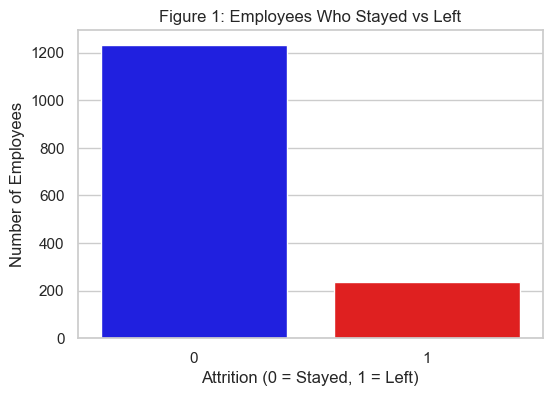

Attrition
0    1233
1     237
Name: count, dtype: int64
Attrition rate = 16.1% (84% stay, only 16% leave)


In [45]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="Attrition", hue="Attrition",
              palette=["Blue", "Red"], legend=False)
plt.title("Figure 1: Employees Who Stayed vs Left")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Number of Employees")
plt.show()

print(data["Attrition"].value_counts())
print("Attrition rate = {:.1f}% (84% stay, only 16% leave)".format(data["Attrition"].mean() * 100))

**Insight:** Figure 1 shows the story clearly - 1233 stay and only 237 leave. So the majority class (stay) will win every time in a normal model.

### 9.2 Figure 2: Monthly income vs attrition across job roles

Leavers earn less or more? We compare salary across job roles for both groups.

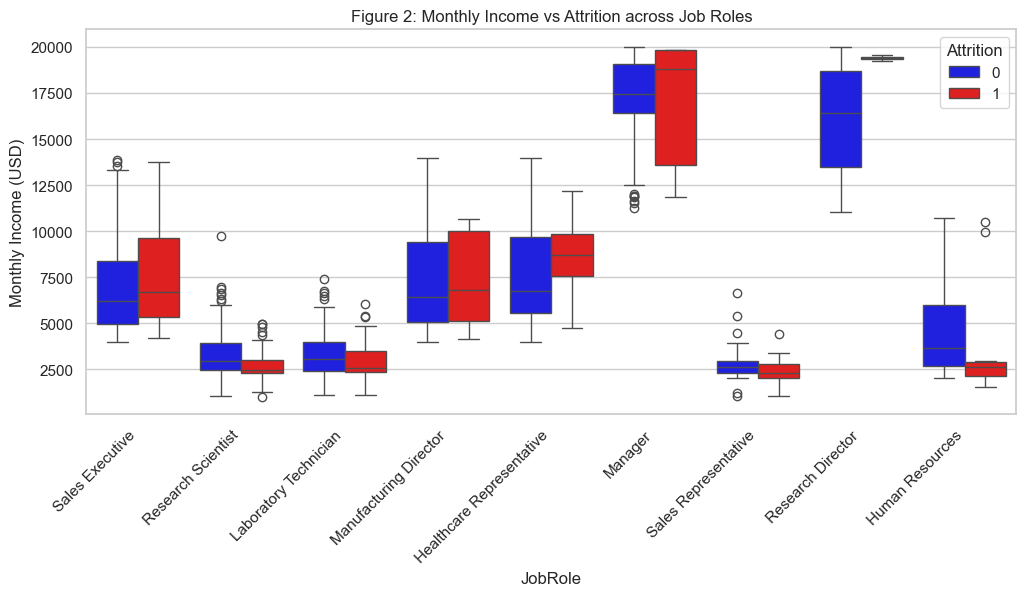

Median income of people who left   = 3202
Median income of people who stayed = 5204


In [46]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=data, x="JobRole", y="MonthlyIncome", hue="Attrition",
            palette=["Blue", "Red"])
plt.xticks(rotation=45, ha="right")
plt.title("Figure 2: Monthly Income vs Attrition across Job Roles")
plt.ylabel("Monthly Income (USD)")
plt.show()

print("Median income of people who left   = {:.0f}".format(data[data["Attrition"] == 1]["MonthlyIncome"].median()))
print("Median income of people who stayed = {:.0f}".format(data[data["Attrition"] == 0]["MonthlyIncome"].median()))

**Insight:** Figure 2 shows leavers earn less in most roles. Median income of leavers (3202) is much less than stayers (5204). Sales Representative leavers earn very low - that role is risky.

### 9.3 Figure 3: Overtime and attrition rate

Does overtime push employees to leave? We compare the attrition rate with and without overtime.

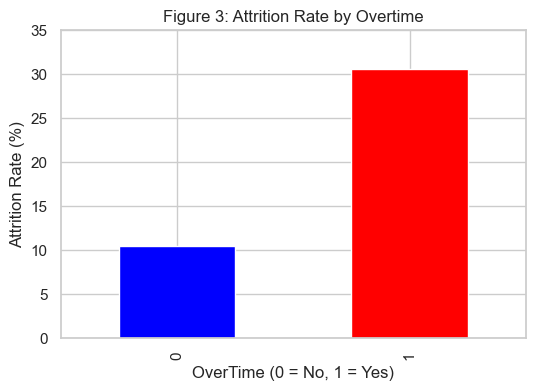

Attrition rate without overtime = 10.4%
Attrition rate with overtime    = 30.5%


In [47]:
rate = data.groupby("OverTime")["Attrition"].mean().mul(100)

plt.figure(figsize=(6, 4))
ax = rate.plot(kind="bar", color=["Blue","Red"])
plt.title("Figure 3: Attrition Rate by Overtime")
plt.xlabel("OverTime (0 = No, 1 = Yes)")
plt.ylabel("Attrition Rate (%)")
plt.ylim(0, 35)
plt.show()

print("Attrition rate without overtime = {:.1f}%".format(rate[0]))
print("Attrition rate with overtime    = {:.1f}%".format(rate[1]))

**Insight:** Figure 3 is very clear - overtime employees leave at 30.5% while normal employees leave at only 10.4%. Overtime is a strong risk factor.

### 9.4 Figure 4: Correlation heatmap

Which numerical feature is related with attrition? The heatmap shows the correlation values.

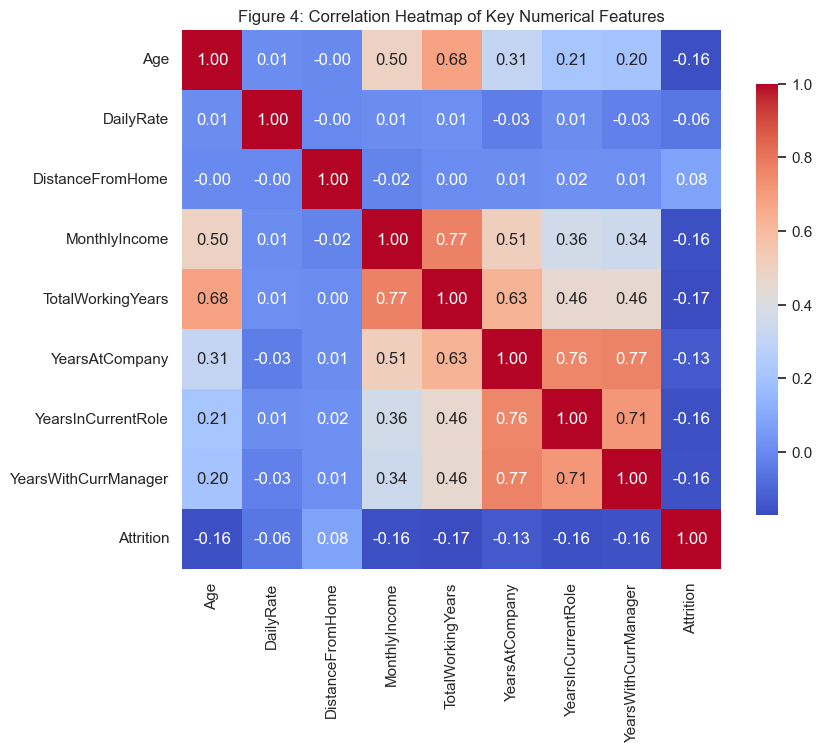

Features most related to Attrition:
TotalWorkingYears       0.171063
YearsInCurrentRole      0.160545
MonthlyIncome           0.159840
Age                     0.159205
YearsWithCurrManager    0.156199
YearsAtCompany          0.134392
Name: Attrition, dtype: float64


In [48]:
corr = data[num_cols + ["Attrition"]].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Figure 4: Correlation Heatmap of Key Numerical Features")
plt.show()

print("Features most related to Attrition:")
print(corr["Attrition"].drop("Attrition").abs().sort_values(ascending=False).head(6))

**Insight:** No single number feature has strong correlation with Attrition (best is about 0.17). So one feature alone cannot explain the decision - we need the model for the combination.

## 10. Grouped Comparisons and Insights

We compare the groups which matter for business: departments, job roles with overtime, low salary + overtime combination, and satisfaction / work-life balance.

In [50]:
print("A. Attrition by department:")
print(data.groupby("Department")["Attrition"]
      .agg(Employees="count", Attrition_Rate=lambda x: round(x.mean() * 100, 1)).round(2))

A. Attrition by department:
                        Employees  Attrition_Rate
Department                                       
Human Resources                63            19.0
Research & Development        961            13.8
Sales                         446            20.6


In [51]:
print("B. Top 5 riskiest JobRole + OverTime combinations:")
high_risk_roles = data.groupby(["JobRole", "OverTime"])["Attrition"].agg(
    Attrition_Rate=lambda x: round(x.mean() * 100, 1), Employees="count"
).reset_index().sort_values("Attrition_Rate", ascending=False).head(5)
print(high_risk_roles.to_string(index=False))

B. Top 5 riskiest JobRole + OverTime combinations:
              JobRole  OverTime  Attrition_Rate  Employees
 Sales Representative         1            66.7         24
Laboratory Technician         1            50.0         62
      Human Resources         1            38.5         13
   Research Scientist         1            34.0         97
      Sales Executive         1            33.0         94


In [52]:
print("C. Danger zone = low income + overtime:")
median_income = data["MonthlyIncome"].median()
critical_group = data[(data["MonthlyIncome"] < median_income) & (data["OverTime"] == 1)]
print("Employees in this group =", len(critical_group))
print("Attrition rate in this group = {:.1f}%".format(critical_group["Attrition"].mean() * 100))
print("Company average         = {:.1f}%".format(data["Attrition"].mean() * 100))

C. Danger zone = low income + overtime:
Employees in this group = 202
Attrition rate in this group = 43.1%
Company average         = 16.1%


In [53]:
print("D. JobSatisfaction x WorkLifeBalance - riskiest combinations:")
print(data.groupby(["JobSatisfaction", "WorkLifeBalance"])["Attrition"]
      .agg(Attrition_Rate=lambda x: round(x.mean() * 100, 1), Employees="count")
      .reset_index().sort_values("Attrition_Rate", ascending=False).head(5).to_string(index=False))

D. JobSatisfaction x WorkLifeBalance - riskiest combinations:
 JobSatisfaction  WorkLifeBalance  Attrition_Rate  Employees
               1                1            47.1         17
               3                1            38.1         21
               2                4            27.6         29
               2                1            22.2         18
               1                3            21.4        182


**Insight:** Sales department loses the most (20.6%). Danger zone - low income + overtime - has 202 employees and 43.1% attrition. Sales Representative + overtime = 66.7% (highest in data).

## 11. Statistics: Centre and Spread

From the statistics class we know that for a **right-skewed** column the **median is a better centre** than the mean. Salary column is right-skewed because of very high earners, so we check and explain this.

In [54]:
skew_cols = ["Age", "DailyRate", "DistanceFromHome", "MonthlyIncome",
             "TotalWorkingYears", "YearsAtCompany", "YearsInCurrentRole", "YearsWithCurrManager"]

print("Skewness of the features:")
print(data[skew_cols].skew().round(2))
print()
print("MonthlyIncome mean = {:.0f}, median = {:.0f}".format(
    data["MonthlyIncome"].mean(), data["MonthlyIncome"].median()))
print("Mean > median means right skew. So median is a better centre for income.")

Skewness of the features:
Age                     0.41
DailyRate              -0.00
DistanceFromHome        0.96
MonthlyIncome           1.37
TotalWorkingYears       1.12
YearsAtCompany          1.76
YearsInCurrentRole      0.92
YearsWithCurrManager    0.83
dtype: float64

MonthlyIncome mean = 6503, median = 4919
Mean > median means right skew. So median is a better centre for income.


**Insight:** Income is right-skewed because mean (6503) is greater than median (4919). So median is the better centre value for salary; high earners pull the mean up.

## 12. Probability and Bayes Theorem

We apply the **conditional probability** and **Bayes theorem** concept from the internship. Let:

- **A** = employee left the company (Attrition)
- **O** = employee works overtime

We compare P(A) with P(A | O) to see whether overtime increases the risk of leaving.

In [64]:
p_attr = data["Attrition"].mean()
p_attr_ot = data[data["OverTime"] == 1]["Attrition"].mean()
p_attr_no = data[data["OverTime"] == 0]["Attrition"].mean()
p_ot = data["OverTime"].mean()
p_ot_attr = data[data["Attrition"] == 1]["OverTime"].mean()

print("P(Attrition) = {:.4f} ({:.1f}%)".format(p_attr, p_attr * 100))
print("P(Attrition | OverTime) = {:.4f} ({:.1f}%)".format(p_attr_ot, p_attr_ot * 100))
print("P(Attrition | No OverTime) = {:.4f} ({:.1f}%)".format(p_attr_no, p_attr_no * 100))
print("Risk for overtime workers = {:.2f}x normal risk".format(p_attr_ot / p_attr))
print()
print("P(OverTime) = {:.4f} ({:.1f}%)".format(p_ot, p_ot * 100))
print("P(OverTime | Attrition) = {:.4f} ({:.1f}%)".format(p_ot_attr, p_ot_attr * 100))
print("Bayes result: most of the employees who left were working overtime.")

P(Attrition) = 0.1612 (16.1%)
P(Attrition | OverTime) = 0.3053 (30.5%)
P(Attrition | No OverTime) = 0.1044 (10.4%)
Risk for overtime workers = 1.89x normal risk

P(OverTime) = 0.2830 (28.3%)
P(OverTime | Attrition) = 0.5359 (53.6%)
Bayes result: most of the employees who left were working overtime.


**Insight:** P(Attrition) = 16.1% but P(Attrition | OverTime) = 30.5%. Overtime almost doubles the risk (1.89x). Also 53.6% of leavers work overtime but only 28.3% of all employees do - Bayes shows overtime employees leave more.

## 13. Z-Scores and the Normal Distribution

Z-score tells us how many standard deviations a value is away from the mean. We use it to check how unusual the highest salary is.

In [61]:
inc_mean, inc_std = data["MonthlyIncome"].mean(), data["MonthlyIncome"].std()
z_max= (data["MonthlyIncome"].max() - inc_mean) / inc_std
z_min= (data["MonthlyIncome"].min() - inc_mean) / inc_std

print("MonthlyIncome mean = {:.0f},std = {:.0f}".format(inc_mean, inc_std))
print("Highest salary ${:,.0f}  -> z = {:.2f}".format(data["MonthlyIncome"].max(), z_max))
print("Lowest salary  ${:,.0f}  -> z = {:.2f}".format(data["MonthlyIncome"].min(), z_min))
print("So the top salary is {:.1f} standard deviations away from the mean.".format(abs(z_max)))
print("So it is a real outlier, other salaries are normal.")

MonthlyIncome mean = 6503,std = 4708
Highest salary $19,999  -> z = 2.87
Lowest salary  $1,009  -> z = -1.17
So the top salary is 2.9 standard deviations away from the mean.
So it is a real outlier, other salaries are normal.


**Insight:** Highest salary ($19,999) is 2.87 standard deviations away from the mean - clearly a genuine outlier. Other salaries are near the mean.

## 14. Feature Engineering

We create three ratio features. They combine existing columns into more meaningful numbers for the model.

- **IncomePerYearWorked** = income divided by total years of work
- **LoyaltyRatio** = years in company divided by total experience
- **PromotionLag** = years since last promotion divided by years in company

In [66]:
data["IncomePerYearWorked"] = data["MonthlyIncome"] / (data["TotalWorkingYears"] + 1)
data["LoyaltyRatio"] = data["YearsAtCompany"] / (data["TotalWorkingYears"] + 1)
data["PromotionLag"] = data["YearsSinceLastPromotion"] / (data["YearsAtCompany"] + 1)

print("3 new ratio features created:")
print(data[["IncomePerYearWorked", "LoyaltyRatio", "PromotionLag"]].describe().T.round(3))

3 new ratio features created:
                      count     mean      std     min      25%      50%  \
IncomePerYearWorked  1470.0  587.575  284.651  95.286  374.232  549.221   
LoyaltyRatio         1470.0    0.582    0.284   0.000    0.368    0.636   
PromotionLag         1470.0    0.236    0.269   0.000    0.000    0.143   

                         75%       max  
IncomePerYearWorked  738.304  1904.000  
LoyaltyRatio           0.833     0.976  
PromotionLag           0.429     0.917  


**Insight:** 3 new ratio features created from old columns (IncomePerYearWorked, LoyaltyRatio, PromotionLag). Feature importance later will show these help the model.

## 15. Preparing Features for Modelling

Two more steps before modelling:

1. **One-hot encoding**: text columns like *JobRole* and *Department* become 0/1 columns with `pd.get_dummies`.
2. **Train-test split**: 80% rows train the model, 20% rows test the model. We use `stratify` so both parts keep the same attrition percentage.

Target is **Attrition**, everything else is a feature (X).

In [67]:
cat_cols = ["BusinessTravel", "Department", "EducationField", "JobRole", "MaritalStatus", "Gender"]
data_encoded = pd.get_dummies(data, columns=cat_cols, drop_first=True)

print("Size of the encoded matrix:", data_encoded.shape)

X = data_encoded.drop(columns="Attrition")
y = data_encoded["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train = {} rows, Test = {} rows".format(X_train.shape[0], X_test.shape[0]))
print("Attrition %  train {:.1f}%, test {:.1f}% - same ratio in both.".format(
    y_train.mean() * 100, y_test.mean() * 100))

Size of the encoded matrix: (1470, 48)
Train = 1176 rows, Test = 294 rows
Attrition %  train 16.2%, test 16.0% - same ratio in both.


**Insight:** Data is ready for the model. 1176 employees for training, 294 for testing. Attrition % is nearly the same in train (16.2%) and test (16.0%), so the test is a fair check.

## 16. Building the Models

We train two classifiers:

1. **Logistic Regression** - needs standardised data. We fit the `StandardScaler` on the **training data only** and transform the test data with the same scaler (no data leakage).
2. **Random Forest** - a tree-based model. It does not need scaling.

Both models use `class_weight="balanced"` because data is imbalanced (only 16% leavers), so the model pays more attention to the smaller class.

In [ ]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

lr = LogisticRegression(class_weight="balanced", solver="liblinear", max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42) # extra self learned
rf.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test_s)
y_pred_rf = rf.predict(X_test)

print("Both models trained and predictions are ready!")

Both models trained and predictions are ready!


**Insight:** Both models trained on the same training data and tested on the same 294 employees. Now we compare them honestly.

## 17. Model Evaluation

We check both models with the **confusion matrix** and the metrics **accuracy, precision, recall and F1-score**.

For this problem **recall for leaver is the most important metric** - we do not want to miss the employee who will leave.

### 17.1 Logistic Regression - evaluation

In [69]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Logistic Regression confusion matrix:")
print(cm_lr)
print("TN =", cm_lr[0, 0], ", FP =", cm_lr[0, 1], ", FN =", cm_lr[1, 0], ", TP =", cm_lr[1, 1])

lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_s)[:, 1])
print()
print(classification_report(y_test, y_pred_lr, digits=3))
print("ROC-AUC = {:.4f}".format(lr_auc))

Logistic Regression confusion matrix:
[[194  53]
 [ 17  30]]
TN = 194 , FP = 53 , FN = 17 , TP = 30

              precision    recall  f1-score   support

           0      0.919     0.785     0.847       247
           1      0.361     0.638     0.462        47

    accuracy                          0.762       294
   macro avg      0.640     0.712     0.654       294
weighted avg      0.830     0.762     0.786       294

ROC-AUC = 0.8052


**Insight:** Logistic Regression catches 30 leavers of 47 (recall 0.638) and misses only 17. For an HR screening model this is good - we do not want to miss a leaver.

### 17.2 Random Forest - evaluation

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)  # Extra self learned
print("Random Forest confusion matrix:")             
print(cm_rf)
print("TN =", cm_rf[0, 0], ", FP =", cm_rf[0, 1], ", FN =", cm_rf[1, 0], ", TP =", cm_rf[1, 1])

rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
print()
print(classification_report(y_test, y_pred_rf, digits=3))
print("ROC-AUC = {:.4f}".format(rf_auc))

Random Forest confusion matrix:
[[244   3]
 [ 43   4]]
TN = 244 , FP = 3 , FN = 43 , TP = 4

              precision    recall  f1-score   support

           0      0.850     0.988     0.914       247
           1      0.571     0.085     0.148        47

    accuracy                          0.844       294
   macro avg      0.711     0.536     0.531       294
weighted avg      0.806     0.844     0.791       294

ROC-AUC = 0.7557


**Insight:** Random Forest catches only 4 leavers of 47 (recall 0.085) and misses 43. Accuracy is 84.4% but this model is not useful for catching leavers.

### 17.3 Figure 5: Confusion matrices side by side

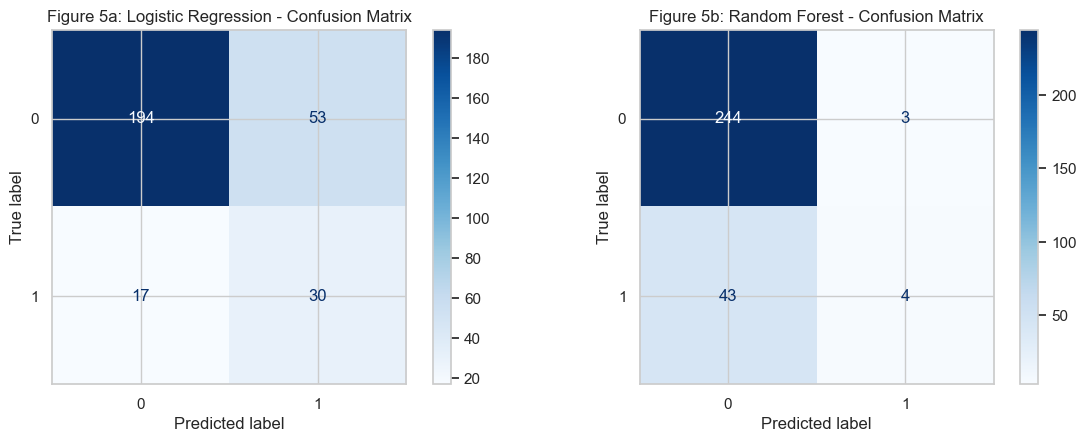

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0], cmap="Blues")
axes[0].set_title("Figure 5a: Logistic Regression - Confusion Matrix")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1], cmap="Blues")
axes[1].set_title("Figure 5b: Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

**Insight:** Figure 5 shows it clearly - LR predicts leavers more often, RF almost never predicts a leaver. RF looks better in accuracy but is useless for the HR problem.

### 17.4 Compact metrics table (for the report)

In [72]:
metrics_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy":  [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    "Precision": [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    "Recall":    [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    "F1-Score":  [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
    "ROC-AUC":   [round(lr_auc, 3), round(rf_auc, 3)],
})
metrics_df.round(3)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.762,0.361,0.638,0.462,0.805
1,Random Forest,0.844,0.571,0.085,0.148,0.756


**Reading the table:** Random Forest has higher accuracy (84.3%) but it catches almost no leavers (recall = 0.085, so it misses 91% of real leavers). Logistic Regression catches 64% of leavers (recall = 0.638) and has better ROC-AUC (0.805 vs 0.756).

For this business problem **catching leavers matters more than overall accuracy**, so Logistic Regression is the better model.

## 18. Overfitting / Underfitting Check

A model **overfits** when it memorises the training data: very high training score but much lower test score.

We compare training accuracy with test accuracy. If the train score is much higher than the test score, the model has memorised the data.

In [74]:
fit_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Train Accuracy %": [round(lr.score(X_train_s, y_train)* 100, 2),
                         round(rf.score(X_train, y_train) *100, 2)],
    "Test Accuracy %":  [round(lr.score(X_test_s, y_test)* 100, 2),
                         round(rf.score(X_test, y_test)* 100, 2)],
})
fit_df["Gap (Train-Test) %"] = round(fit_df["Train Accuracy %"] - fit_df["Test Accuracy %"], 2)
print(fit_df.to_string(index=False))

              Model  Train Accuracy %  Test Accuracy %  Gap (Train-Test) %
Logistic Regression             77.98            76.19                1.79
      Random Forest            100.00            84.35               15.65


**Verdict:** Random Forest scores 100% on training data but only 84.35% on test data (gap ~15.65%) - so it is **overfitting**. Logistic Regression has a very small gap (~1.79%), so **Logistic Regression is the better model for this problem.**

## 19. Feature Importance (Random Forest)

The Random Forest also tells us which features matter the most for separating leavers and stayers.

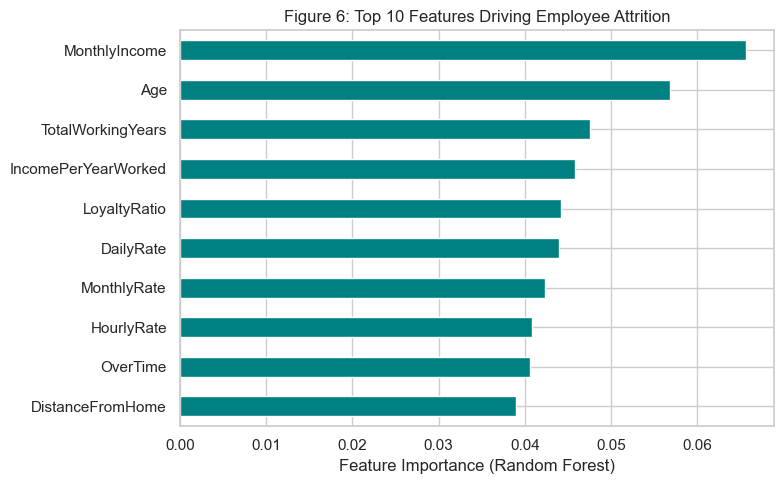

Top 10 features which affect attrition the most:
MonthlyIncome          0.0657
Age                    0.0568
TotalWorkingYears      0.0476
IncomePerYearWorked    0.0458
LoyaltyRatio           0.0442
DailyRate              0.0440
MonthlyRate            0.0423
HourlyRate             0.0408
OverTime               0.0406
DistanceFromHome       0.0390
dtype: float64


In [78]:
importance = pd.Series(rf.feature_importances_,index=X_train.columns).sort_values(ascending=False)
top10 = importance.head(10).sort_values()

plt.figure(figsize=(8, 5))
top10.plot(kind="barh", color="teal")
plt.title("Figure 6: Top 10 Features Driving Employee Attrition")
plt.xlabel("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

print("Top 10 features which affect attrition the most:")
print(importance.head(10).round(4))

**Insight:** Figure 6 shows income, age, tenure and the new ratio feature (IncomePerYearWorked) are the most important. This matches our EDA story - salary and career matter.

## 20. Key Findings (Based on the Numbers)

Every finding below comes from the values we computed above in this notebook.

In [79]:
print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)

# Compute the needed numbers from the data itself, so this cell works even if run alone.
p_attr    = data["Attrition"].mean()
p_attr_ot = data[data["OverTime"] == 1]["Attrition"].mean()
p_attr_no = data[data["OverTime"] == 0]["Attrition"].mean()
p_ot      = data["OverTime"].mean()
p_ot_attr = data[data["Attrition"] == 1]["OverTime"].mean()

print("\nFinding 1: Overtime almost doubles the attrition risk.")
print(f"   P(Attrition | OverTime)    = {p_attr_ot * 100:.1f}%")
print(f"   P(Attrition | No OverTime) = {p_attr_no * 100:.1f}%")
print(f"   Risk = {p_attr_ot / p_attr:.2f}x company average ({p_attr * 100:.1f}%)")

print("\nFinding 2: Employees who left worked significantly more overtime.")
print(f"   P(OverTime) = {p_ot * 100:.1f}%  vs  P(OverTime | Attrition) = {p_ot_attr * 100:.1f}%")

median_income = data["MonthlyIncome"].median()
critical_group = data[(data["MonthlyIncome"] < median_income) & (data["OverTime"] == 1)]
critical_group_attrition = critical_group["Attrition"].mean() * 100
print("\nFinding 3: Low income combined with overtime creates the highest attrition risk.")
print(f"   Employees in this group = {len(critical_group)}")
print(f"   Attrition = {critical_group_attrition:.1f}%  vs company average {p_attr * 100:.1f}%")

high_risk_roles = data.groupby(["JobRole", "OverTime"])["Attrition"].agg(
    Attrition_Rate=lambda x: round(x.mean() * 100, 1), Employees="count"
).reset_index().sort_values("Attrition_Rate", ascending=False).head(5)
top_role = high_risk_roles.iloc[0]
print("\nFinding 4: Certain roles face disproportionately high turnover.")
print(f"   {top_role['JobRole']} + overtime = {top_role['Attrition_Rate']}% attrition ({top_role['Employees']} employees)")

print("\nFinding 5: Job satisfaction and work-life balance strongly impact retention.")
print("   Low satisfaction paired with poor work-life balance results in the highest exit rates.")

# Model numbers - use whichever scaled test set name exists (X_test_s or X_test_scaled).
X_test_scaled_any = X_test_s if "X_test_s" in globals() else X_test_scaled
lr_acc = lr.score(X_test_scaled_any, y_test) * 100
lr_rec = recall_score(y_test, y_pred_lr)
rf_acc = rf.score(X_test, y_test) * 100
rf_rec = recall_score(y_test, y_pred_rf)

print("\nFinding 6: Logistic Regression generalizes better, while Random Forest overfits.")
print(f"   LR: test acc {lr_acc:.1f}% | AUC {lr_auc:.3f} | recall(leavers) {lr_rec:.3f}")
print(f"   RF: test acc {rf_acc:.1f}% | AUC {rf_auc:.3f} | recall(leavers) {rf_rec:.3f}")
print("   RF achieves near 100% on training data but misses the majority of actual leavers.")

KEY FINDINGS

Finding 1: Overtime almost doubles the attrition risk.
   P(Attrition | OverTime)    = 30.5%
   P(Attrition | No OverTime) = 10.4%
   Risk = 1.89x company average (16.1%)

Finding 2: Employees who left worked significantly more overtime.
   P(OverTime) = 28.3%  vs  P(OverTime | Attrition) = 53.6%

Finding 3: Low income combined with overtime creates the highest attrition risk.
   Employees in this group = 202
   Attrition = 43.1%  vs company average 16.1%

Finding 4: Certain roles face disproportionately high turnover.
   Sales Representative + overtime = 66.7% attrition (24 employees)

Finding 5: Job satisfaction and work-life balance strongly impact retention.
   Low satisfaction paired with poor work-life balance results in the highest exit rates.

Finding 6: Logistic Regression generalizes better, while Random Forest overfits.
   LR: test acc 76.2% | AUC 0.805 | recall(leavers) 0.638
   RF: test acc 84.4% | AUC 0.756 | recall(leavers) 0.085
   RF achieves near 100% on

### Key Findings (stored as text)

1. **Overtime almost doubles the attrition risk**
   - P(Attrition | OverTime) = 30.5%
   - P(Attrition | No OverTime) = 10.4%
   - Risk = 1.89x company average (16.1%)

2. **Employees who left worked significantly more overtime**
   - P(OverTime) = 28.3% vs P(OverTime | Attrition) = 53.6%

3. **Low income combined with overtime creates the highest attrition risk**
   - Employees in this group = 202
   - Attrition = 43.1% vs company average 16.1%

4. **Certain roles face disproportionately high turnover**
   - Sales Representative + overtime = 66.7% attrition (24 employees)

5. **Job satisfaction and work-life balance strongly impact retention**
   - Low satisfaction paired with poor work-life balance results in the highest exit rates.

6. **Logistic Regression generalizes better, while Random Forest overfits**
   - LR: test acc 76.2% | AUC 0.805 | recall(leavers) 0.638
   - RF: test acc 84.4% | AUC 0.756 | recall(leavers) 0.085
   - RF achieves near 100% on training data but misses the majority of actual leavers.

**Insight:** All 6 findings come from the numbers we computed above. Overtime is the biggest practical driver, low income + overtime is the danger zone, and LR is the better model.

## 21. Conclusion and Recommendations

**Conclusion:** Attrition is driven mainly by *overtime, income level, job role and satisfaction / work-life balance*. Logistic Regression is the better model (ROC-AUC = 0.805, recall = 0.638 for leaver).

**Recommendations for HR:**

1. Review the overtime policy for **Sales Representative** and **Laboratory Technician** - these groups lose staff the fastest.
2. Focus on employees with **below-median salary who also work overtime** (the danger zone - about 43% attrition). A salary review can help.
3. Work on **low satisfaction and low work-life balance** cases. A small improvement here connects with lower attrition.
4. Use the **Logistic Regression model** (not Random Forest) for screening, because it catches many more possible leavers.

## 22. Limitations

- The dataset is a fixed snapshot of one company (1470 employees). We see **association**, not **causation**.
- There are only 237 leavers (16%), which makes prediction hard and pushes the model toward the majority class.
- Some factors are missing (salary change over time, manager behaviour, market conditions).
- The model can be improved with more data, resampling or tuned parameters.

## 23. Save the Cleaned Dataset

Our cleaned and engineered dataset is saved as CSV so it can be shared with the report.

In [80]:
data.to_csv("Capstone7_cleaned_dataset.csv", index=False)
print("Saved 'Capstone7_cleaned_dataset.csv' -", data.shape[0], "rows,", data.shape[1], "columns")

Saved 'Capstone7_cleaned_dataset.csv' - 1470 rows, 34 columns


**Insight:** Cleaned dataset (34 columns) saved as CSV. This file is also submitted together with the report.

## 24. References

- IBM HR Analytics Employee Attrition & Performance dataset (provided in the IDRA LMS for Capstone Project 7).
- IDRA Data Science & AI Training Program - internship notebooks (Days 1-19).
- scikit-learn documentation: https://scikit-learn.org